# 

# HW 1 - Multiple Linear Regression

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
# # Import raw data file

# input_file = "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2026_1.csv"
# df = pd.read_csv(input_file)

# condition = (df["Reporting_Airline"] == "UA") & (df["Origin"] == "ORD")
# # condition = df["Origin"] == "ORD"

# df_filtered = df[condition]

# columns_to_keep = [
#     # "DayofMonth",
#     "DayOfWeek",
#     # "Reporting_Airline",
#     # "Origin",
#     # "Dest",
#     "DepTime",
#     "TaxiOut"
# ]

# fdata = df_filtered[columns_to_keep].copy()

# for col in columns_to_keep:
#     fdata[col] = pd.to_numeric(fdata[col], errors="coerce")

# fdata = fdata.dropna(subset=columns_to_keep) # delete N/A data

# hours = fdata["DepTime"] // 100 # change "hhmm" to [min] of the day
# minutes = fdata["DepTime"] % 100

# fdata["DepTime_Min"] = np.where(
#     fdata["DepTime"] > 0, hours * 60 + minutes, 0.0
# )

# fdata.to_csv("dataset_cleaned.csv", index=False)


fdata = pd.read_csv("dataset_cleaned.csv")
print(fdata.head())

   DayOfWeek  DepTime  TaxiOut  DepTime_Min
0          6   1800.0     19.0       1080.0
1          6    741.0     28.0        461.0
2          6   1622.0     48.0        982.0
3          6   1102.0     28.0        662.0
4          6   1259.0     22.0        779.0


**Dataset Explanation**

The primary objective of this anlysis is to investigate the operational factors influencing airplane taxi-out time. I hypothesize that taxi-out duration is predominatly driven by temporal demand patterns, specificaly the day of the week (DayOfWeek) and the actual departure time of day (DepTime). To encode the categorical variable DayOfWeek, I utilized dummy coding with 7-Sun set as the reference baseline.

To eliminate other variations, I focused on a controlled subset: United Airlines (UA) flights departing from Chicago O'Hare International Airport (ORD).

In addition, the day of week dummy variables are binary, whereas DepTime_Min ranges up to 1440 minutes. Therefore, the following predictor matrix is normalized to [-1, 1] to improve numerical conditioning.
***

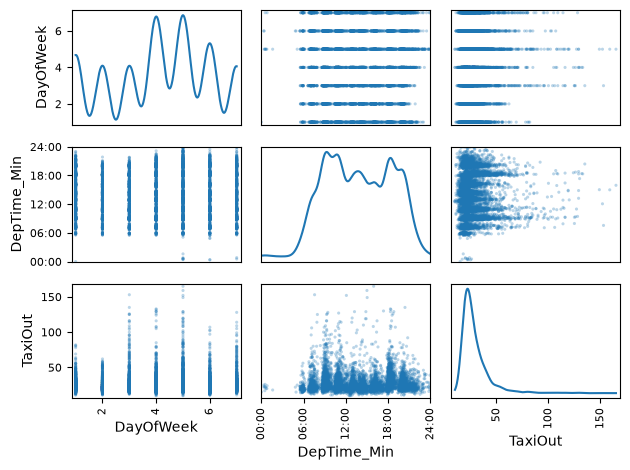

In [14]:
# Scatter Plot

plot_vars = ["DayOfWeek", "DepTime_Min", "TaxiOut"]

axes = pd.plotting.scatter_matrix(
    fdata[plot_vars],
    marker="o",
    s=5,
    alpha=0.3,
    diagonal='kde'
)

tick_mins = [0, 360, 720, 1080, 1440]
tick_labels = ["00:00", "06:00", "12:00", "18:00", "24:00"]

for r in range(3):
    axes[r, 1].set_xlim([0, 1440])
    axes[r, 1].set_xticks(tick_mins)

axes[2, 1].set_xticklabels(tick_labels)

for c in range(3):
    if c != 1:
        axes[1, c].set_ylim([0, 1440])
        axes[1, c].set_yticks(tick_mins)

axes[1, 0].set_yticklabels(tick_labels)

plt.tight_layout()
plt.show()

**Scatter Plot Explanation**

This scatter plot shows the relationships among three variables: DayOfWeek, DepTime_Min, and TaxiOut.

* Diagnal Plots
    - DatOfWeek: Flight operations are distributed across all days of the week; higher traffic volumes concentrated towrad Thr, Fri, and Sat.
    - DepTime_Min: Departures are concentrated between 06:00 and 22:00; showing two distinct operational peaks-one in the late morning and another in the late afternoon.
    - TaxiOut: The distribution is right-skewed; while the majority of data cluster around 30 minutes, notable outliers extend beyond normal operational ranges.

* Off-Diagonal Plots
    - DayOfWeek vs. DepTime_Min: Flight departure schedules are uniformly spread across the operational hours regardless of the specific day of the week.
    - DayOfWeek vs. TaxiOut: Most taxi-out durations remain generally uniform across the week, but extreme long-tail delays occur prominently on Wed and Fri.
    - DepTime_Min vs. TaxiOut: Taxi-out durations are lowest during early morning and late night hours; sporadically large taxi-out delays appear throughtout the daytime operational window.
***

In [15]:
# X normalized function

def normalize_data(X):
    """Function to normalize input data to [-1, 1].

    Parameters
    ----------
    X : array_like
        Input data (n x (p + 1) dimensions), where each row is an observation and each column is a predictor. The first column should be all ones.

    Returns
    -------
    X_normalized : array_like
        Input data (n x (p + 1) dimensions) normalized to the range [-1, 1].

    """

    n, n_columns = np.shape(X)

    # normalize each column
    X_normalized = np.ones((n, n_columns))
    for column in range(n_columns):
        x_column = X[:, column]
        x_max = max(x_column)
        x_min = min(x_column)
        if x_max != x_min:
            x_column_normalized = [
                (x - (x_max + x_min) / 2) / ((x_max - x_min) / 2) for x in x_column
            ]
            X_normalized[:, column] = x_column_normalized

    return X_normalized

In [16]:
# Make X list: [1, "Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "DepTime_Min"]

for day_code in range(1,7):
    col_name = f"Day_{day_code}"
    fdata[col_name] = (fdata["DayOfWeek"] == day_code).astype(int) # delete 7-Sun

day_dummy_cols = [f"Day_{i}" for i in range(1,7)]
X_cols = day_dummy_cols + ["DepTime_Min"]

X_temp = fdata[X_cols].values
n = len(fdata) # num of data

X = np.concatenate((np.ones((n, 1)), X_temp), axis=1) # put beta_0 column
X_normalized = normalize_data(X) # normalized

y = fdata["TaxiOut"].values.reshape(-1, 1)

In [17]:
# Utilizing `statsmodels` library

results = sm.OLS(y, X_normalized).fit()

X_cols_name = ["const."] + X_cols

# (1) ANOVA model test, (2) individual coefficient hypothesis tests
print(results.summary(xname=X_cols_name))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     31.63
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           1.71e-43
Time:                        23:15:15   Log-Likelihood:                -28505.
No. Observations:                7067   AIC:                         5.703e+04
Df Residuals:                    7059   BIC:                         5.708e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const.         26.4671      1.058     25.007      

In [18]:
print(f"F-statistic: {results.fvalue:.8f}")
print(f"p-value: {results.f_pvalue:.10e}")

F-statistic: 31.62521101
p-value: 1.7084670362e-43


**(1) ANOVA model test**

The model yielded an F-statistics of 31.63 with DoF of model 7 and DoF of residuals 7059, correspoinding to a p-value of 1.71e-43. Because the p-value is substantially lower than the standard threshould, we reject the null hypothesis and confirm that at least one of the predictors in this model is statistically associated with taxi-out duration.
***

In [19]:
for name, coef, tval, pval in zip(X_cols_name, results.params, results.tvalues, results.pvalues):
    print(f"{name:<12}: coef = {coef:10.6f}, t-value = {tval:10.4f}, p-value = {pval:10.8e}")

const.      : coef =  26.467149, t-value =    25.0069, p-value = 2.57770325e-132
Day_1       : coef =  -1.359585, t-value =    -4.2816, p-value = 1.88001629e-05
Day_2       : coef =  -2.105505, t-value =    -6.4944, p-value = 8.90536670e-11
Day_3       : coef =   0.441532, t-value =     1.3609, p-value = 1.73589016e-01
Day_4       : coef =  -0.419547, t-value =    -1.3886, p-value = 1.64987695e-01
Day_5       : coef =   1.708663, t-value =     5.6622, p-value = 1.55288521e-08
Day_6       : coef =  -1.170311, t-value =    -3.7419, p-value = 1.84092445e-04
DepTime_Min : coef =   0.635925, t-value =     1.4756, p-value = 1.40105350e-01


**(2) Individual coefficient hypothesis tests**

- DepTime_Min: This is not statistically significant at the 5% significance level because p = 0.140. Although its estimated coefficient is positive, there is insufficient evidence to conclude that DepTime_Min is significantly affects taxi-out duration after accounting for day of the week.
- Day_5: Fri exhibits statistically significant positive coefficient, indicationg a significantly longer taxi-out duration compared with Sun.
- Day_1, Day_2 and Day_6: Mon, Tue and Sat yield statistically significant negative coefficients, demonstrating substantially less ground queuing than Sunday.
- Day_3 and Day_4: Wed and Thu fail to reject the null hypothesis at the 5% significance level, showing less statistically discernable difference in taxi-out duration relative to Sun.
***

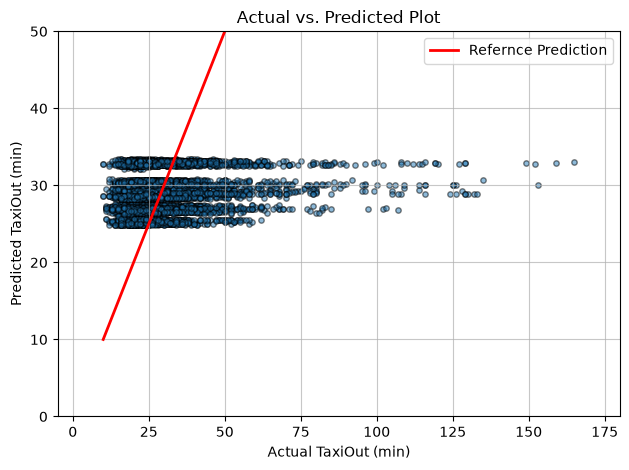

In [20]:
# (3) Actual vs. Predicted plot

y_pred = results.predict(X_normalized)
y_actual = y.flatten()

plt.figure()
plt.scatter(y_actual, y_pred, alpha=0.5, edgecolors='k', s=15)

min_val = min(y_actual.min(), y_pred.min())
max_val = max(y_actual.max(), y_pred.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    label="Refernce Prediction",
)

plt.title("Actual vs. Predicted Plot")
plt.xlabel("Actual TaxiOut (min)")
plt.ylabel("Predicted TaxiOut (min)")
plt.xlim([-5, 180])
plt.ylim([0, 50])
plt.grid(True, alpha=0.7)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

**(3) Actual vs. Predicted plot**

The red line represents the ideal reference prediction; however, the data points do not follow this line, clustering horizontally within a narrow band of 25-35 minutes and failing to capture etreme tail delays.

This behavior is consistent with the model's low coefficient of R_squared = 0.030, indicating that the current feature set explains only a small fraction of the total variance in taxi-out duration. Although the overall regression model is statistically significant, the current predictors are insufficient on their own to model the real nature of airport ground operations.
***